# **RELATÓRIO - LH NAUTICAL ⚓**

## **1 - EDA**

In [11]:
# IMPORTANDO BIBLIOTECAS
import pandas as pd 
import os
from datetime import datetime

# CARREGANDO O DATASET
BASE_DIR = os.getcwd()
PATH_VENDAS = os.path.join(BASE_DIR, '..', 'data', 'raw')
df = pd.read_csv(os.path.join(PATH_VENDAS, 'vendas_2023_2024.csv'))

#### **1.1 - Visão geral do dataset (quantidade de linhas, colunas e intervalo de datas):**

In [12]:
#LINHAS E COLUNAS
print(f"Linhas: {df.shape[0]}\nColunas: {df.shape[1]}")

# CONFERINDO AS DATAS
df_data = df.copy()
df_data['sale_date'] = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True)
print(f"Data mínima: {df_data['sale_date'].min().strftime('%d-%m-%y')} e Data máxima: {df_data['sale_date'].max().strftime('%d-%m-%y')}")

Linhas: 9895
Colunas: 6
Data mínima: 01-01-23 e Data máxima: 31-12-24


#### **1.2 - Análise de valores numéricos da coluna "total":**

In [13]:
#ANÁLISE DA COLUNA TOTAL
print(f"Valor mínimo: {df['total'].min()}")
print(f"Valor máximo: {df['total'].max()}")
print(f"Valor médio: {round(df['total'].mean(), 2)}")
print(f"Mediana: {df['total'].median()}")

#AVALIANDO OUTLIERS PELO MÉTODO INTERQUARTIL
q1 = df['total'].quantile(0.25) 
q3 = df['total'].quantile(0.75)
iqr = q3 - q1
lim_inferior = q1 - 1.5 * iqr
lim_superior = q3 + 1.5 * iqr

outliers_inferiores = df[df['total'] < lim_inferior]
outliers_superiores = df[df['total'] > lim_superior]

print(f"Q1: {q1}\nQ3: {q3}")
print(f"limite inferior: {lim_inferior}\nlimite superior: {lim_superior}")
print(f"outliers inferiores: {outliers_inferiores.shape[0]}")
print(f"outliers superiores: {outliers_superiores.shape[0]}")

# RANKING DE OUTLIERS
outliers_ranking = outliers_superiores.sort_values(by='total', ascending=False)
top_outliers = outliers_ranking[['id_product', 'total']].head(10)
print("Top 10 maiores outliers de vendas:")
display(top_outliers)

Valor mínimo: 294.5
Valor máximo: 2222973.0
Valor médio: 263797.83
Mediana: 82225.0
Q1: 23138.2
Q3: 339094.5
limite inferior: -450796.24999999994
limite superior: 813028.95
outliers inferiores: 0
outliers superiores: 1018
Top 10 maiores outliers de vendas:


,id_product,total
8905,76,2222973.00
3873,76,2222973.00
9623,76,2222973.00
1578,76,2222973.00
7930,73,2147399.00
8856,76,2111824.35
1974,76,2111824.35
8800,76,2074775.00
5014,76,2074775.00
5183,97,2030026.00


Os outliers significativos são os superiores com 1018 casos (cerca de 10% dos dados), que indicam valores  elevados acima dos 2 milhões, principalmente quandoo comparados às medidas de tendencia central deste dataframe. A média de 263 mil evidencia a influência dos extremos de cima.

Além disso, só de observar o ranking dos 10 maiores outliers, percebemos mesmo produto (ID 76) aparecendo multiplas vezes entre os maiores, sendo que em quatro delas com o mesmo valor máximo de R$ 2222973, o que pode nos indicar alguma anomalia, como talvez, registros duplicados.


In [14]:
#ANALISANDO OUTLIERS SUSPEITOS
outliers_suspeitos = df[(df['id_product'] == 76) & (df['total'] > 222900)]
display(outliers_suspeitos.head())

,id,id_client,id_product,qtd,total,sale_date
175,179,41,76,14,1971036.25,2024-09-27
598,608,23,76,4,592793.00,29-11-2023
671,681,32,76,3,422365.25,2024-10-06
737,747,11,76,12,1778379.00,2024-02-13
763,773,36,76,10,1407882.90,04-04-2024


Apesar da possibilidade de comportamento anômalo, com o mesmo produto registrando o mesmo total elevado quatro vezes, podemos visualizar que não se trata de duplicatas:

São apenas compras do mesmo produto em mesma quantidade, realizadas por clientes diferentes em datas distintas.

#### **1.3 - Interpretação e diagnóstico para análises futuras:**

In [18]:
#ANALISANDO VALORES NULOS, NEGATIVOS E DUPLICADOS
valores_nulos = df.isnull().sum()
print(f"Valores nulos:\n{valores_nulos}\n")
valores_negativos = (df.select_dtypes(include='number') < 0).sum()
print(f"Valores negativos:\n{valores_negativos}\n")
valores_duplicados = df.duplicated().sum()
print(f"Valores duplicados:\n {valores_duplicados}")

Valores nulos:
id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64

Valores negativos:
id            0
id_client     0
id_product    0
qtd           0
total         0
dtype: int64

Valores duplicados:
 0


In [131]:
#ANALISANDO FORMATOS DA COLUNA sale_date
df['sale_date'].astype(str).str.replace(r'\d', 'X', regex=True).value_counts()

sale_date
XX-XX-XXXX    4982
XXXX-XX-XX    4913
Name: count, dtype: int64

##### **Conclusão:**
**Os dados são de qualidade, não constando valores nulos, negativos ou duplicados. Entretanto, temos inconsistências no formato padrão de datas da coluna "sale_date", que apresenta dois tipos de configuração.**

**Ademais, podemos considerar o dataset parcialmente apto para prosseguir nas análises, e que estará completamente pronto após solucionadas inconsistências.**

## **2 - PRODUTOS**


In [33]:
#IMPORTANDO BIBLIOTECA
import pandas as pd
import os

# CARREGANDO O DATASET
BASE_DIR = os.getcwd()
PATH_PRODUTOS = os.path.join(BASE_DIR, '..', 'data', 'raw')
PATH_PROCESSED = os.path.join(BASE_DIR, '..', 'data', 'processed')
df = pd.read_csv(os.path.join(PATH_PRODUTOS, 'produtos_raw.csv'))

#### **2.1 - Padronização dos nomes das categorias de produtos (eletrônicos, propulsão e ancoragem):**

In [34]:
# APONTANDO AS CATEGORIAS ÚNICAS 
print(df['actual_category'].unique())

# FUNCÃO PARA NORMALIZAR AS CATEGORIAS DE PRODUTOS
def normalizar_categoria(categoria):
    '''Normaliza a categoria de produtos: retira os espaços, converte para minúsculas e categoriza com base em radicais em comum'''
    categoria = categoria.strip().lower().replace(' ', '')
    if 'el' in categoria:
        return 'eletrônicos'
    elif 'pr' in categoria:
        return 'propulsão'
    elif 'anc' in categoria or 'cor' in categoria:
        return 'ancoragem'
    return categoria

# APLICANDO A FUNÇÃO DE NORMALIZAÇÃO NA COLUNA 'actual_category'
df['actual_category'] = df['actual_category'].apply(normalizar_categoria)

# CONFERINDO RESULTADOS DA NORMALIZAÇÃO
print(f"{df['actual_category'].value_counts()}\n\n Total de registros: {df['actual_category'].value_counts().sum()}")

<StringArray>
[          'ELETRONICOS', 'E L E T R Ô N I C O S',           'Eletrunicos',
           'Eletronicoz',           'eLeTrÔnIcOs',           'eletrônicos',
           'Eletrônicos',          'Eletroniscos',           'Eletronicos',
           'eletronicos',           'EletrônicoS',           'ELEtRÔNICOS',
             'PROPULSAO',             'Propulção',                  'Prop',
            'Propulssão',             'propulsao',     'P R O P U L S Ã O',
              'Propução',             'propulsão',             'pRoPuLsÃo',
             'Propulçao',             'Propulsam',             'PrOpUlSãO',
             'Ancoragem',             'AnCoRaGeM',             'Encoragem',
            'Ancoraguem',              'Ancorajm',             'AncorageM',
     'A N C O R A G E M',             'ANCORAGEM',             'aNcOrAgEm',
             'Ancorajem',              'Encoragi',             'ancoragem',
             'Ancorajen',             'AncorajeM',             'Ancoragen'

#### **2.2 - Conversão de valores para o tipo numérico:**

In [35]:
# ANTES DE CONVERTER, NECESSÁRIO RETIRAR CARACTERES DE CIFRÃO
df['price'] = df['price'].astype(str).str.replace('R$', '').str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

#CONFERINDO RESULTADOS DA CONVERSÃO
print(f"Tipo da coluna price: {df['price'].dtype}")
print(f"Qtd dos valores convertidos: {df['price'].value_counts().sum()}")

Tipo da coluna price: float64
Qtd dos valores convertidos: 157


#### **2.3 - Remoção de duplicados:**

In [36]:
#REMOVENDO REGISTROS DUPLICADOS
antes_remocao = len(df)
df = df.drop_duplicates()
depois_remocao = len(df)
print(f"Registros removidos: {antes_remocao - depois_remocao}\n")
print(f"Dataset com {depois_remocao} linhas normalizadas e sem duplicatas.")


Registros removidos: 7

Dataset com 150 linhas normalizadas e sem duplicatas.


In [37]:
#SALVANDO O DATASET NORMALIZADO
df.to_csv(os.path.join(PATH_PROCESSED, 'produtos_normalizados.csv'), index=False)

## **3 - CUSTOS DE IMPORTAÇÃO**

In [137]:
#IMPORTANDO BIBLIOTECAS
import pandas as pd
import json
import os

#### **3.1 - Carregar o JSON e gerar novo arquivo CSV:**

In [138]:
#CARREGANDO JSON
BASE_DIR = os.getcwd()
PATH_RAW = os.path.join(BASE_DIR, '..', 'data', 'raw')
PATH_PROCESSED = os.path.join(BASE_DIR, '..', 'data', 'processed')

with open(os.path.join(PATH_RAW, 'custos_importacao.json'), 'r', encoding='utf-8') as arquivo_json:
    dados = json.load(arquivo_json)

# DESANINHANDO JSON PARA CRIAR O DATAFRAME
df_custos_importacao = pd.json_normalize(dados,
                                         record_path=['historic_data'],
                                         meta=['product_id', 'product_name', 'category'])

df_custos_importacao = df_custos_importacao[[
    'product_id', 'product_name', 'category', 'start_date', 'usd_price']]

# EXIBINDO AS PRIMEIRAS LINHAS, AS ÚLTIMAS LINHAS E O FORMATO DO DATAFRAME
display(df_custos_importacao.head(2))
display(df_custos_importacao.tail(2))
print(df_custos_importacao.shape)

#AVALIANDO OS TIPOS DE DADOS
print(f"Tipos de dados:\n{df_custos_importacao.dtypes}")

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,10/08/2016,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,15/06/2018,8778.36


,product_id,product_name,category,start_date,usd_price
1258,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,04/10/2024,300.96
1259,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,25/10/2024,288.90


(1260, 5)
Tipos de dados:
product_id       object
product_name        str
category            str
start_date          str
usd_price       float64
dtype: object


In [139]:
# CONVERTENDO TIPOS DE DADOS
df_custos_importacao['product_id'] = df_custos_importacao['product_id'].astype(
    int)  

df_custos_importacao['start_date'] = pd.to_datetime(df_custos_importacao['start_date'], 
                                                    errors='coerce', 
                                                    dayfirst=True)

df_custos_importacao['usd_price'] = pd.to_numeric(df_custos_importacao['usd_price'], 
                                                  errors='coerce')

print(f"\nTipos de dados convertidos:\n{df_custos_importacao.dtypes}")
display(df_custos_importacao.head(3))
print(f"Qtd de entradas atualizadas pós normalização: {df_custos_importacao.shape[0]}")




Tipos de dados convertidos:
product_id               int64
product_name               str
category                   str
start_date      datetime64[us]
usd_price              float64
dtype: object


,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87


Qtd de entradas atualizadas pós normalização: 1260


In [140]:
# SALVANDO EM CSV
df_custos_importacao.to_csv(os.path.join(PATH_PROCESSED, 'custos_importacao.csv'), index=False)

## **4 - DADOS PÚBLICOS**

In [38]:
#IMPORTANDO BIBLIOTECAS
import pandas as pd
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import FuncFormatter

# CONFIGURANDO PATHS
BASE_DIR = os.getcwd()
PATH_RAW = os.path.join(BASE_DIR, '..', 'data', 'raw')
PATH_PROCESSED = os.path.join(BASE_DIR, '..', 'data', 'processed')
PATH_PLOTS = os.path.join(BASE_DIR, '..', 'notebook', 'plots')


#### **4.1 - Cálculo e modelagem:**

In [39]:
# EXTRAINDO COTAÇÕES DO DÓLAR

#API do BACEN para obter as cotações do dólar entre 30 de dezembro de 2022 e 31 dezembro de 2024
url = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='12-30-2022'&@dataFinalCotacao='12-31-2024'&$format=json" 

# REQUISITANDO API E CONVERTENDO EM DATAFRAME
response = requests.get(url)
data = response.json()
df_cambio = pd.DataFrame(data['value'])

# CONVERTENDO A COLUNA DE DATA PARA O FORMATO CORRETO E EXTRAINDO APENAS A DATA
df_cambio['dataHoraCotacao'] = pd.to_datetime(df_cambio['dataHoraCotacao'])
df_cambio['data'] = df_cambio['dataHoraCotacao'].dt.date

#RENOMEANDO AS COLUNAS PARA FICAR MAIS CLARO
df_cambio = df_cambio.rename(columns={'cotacaoVenda': 'cotacao_vendas'})
df_cambio = df_cambio.rename(columns={'data': 'cotacao_data'})

# MÉDIA DIÁRIA DA COTAÇÃO DE VENDA DO DÓLAR
df_cambio = df_cambio.groupby('cotacao_data')['cotacao_vendas'].mean().reset_index()
display(df_cambio.head(10))

# SALVANDO O DATAFRAME DE COTAÇÃO EM CSV
df_cambio.to_csv(os.path.join(PATH_PROCESSED, 'cambio.csv'), index=False)


,cotacao_data,cotacao_vendas
0,2022-12-30,5.2177
1,2023-01-02,5.3436
2,2023-01-03,5.3759
3,2023-01-04,5.4459
4,2023-01-05,5.4026
5,2023-01-06,5.2855
6,2023-01-09,5.2967
7,2023-01-10,5.2395
8,2023-01-11,5.2020
9,2023-01-12,5.1400


In [40]:
# AGREGANDO DADOS DE VENDAS, CUSTOS DE IMPORTAÇÃO E COTAÇÃO

# CARREGANDO OS DADOS DE VENDAS, CUSTOS DE IMPORTAÇÃO E COTAÇÃO DO DÓLAR
df_vendas = pd.read_csv(os.path.join(PATH_RAW, 'vendas_2023_2024.csv'))             
df_custos = pd.read_csv(os.path.join(PATH_PROCESSED, 'custos_importacao.csv'))
df_cambio = pd.read_csv(os.path.join(PATH_PROCESSED, 'cambio.csv')) 

#FORMATANDO A COLUNA sale_date PARA O FORMATO DE DATA, CONSIDERANDO OS DIFERENTES FORMATOS ENCONTRADOS
def format_saledata(valor):
    if not isinstance(valor, str): return valor
    if valor[4] == '-': 
        return pd.to_datetime(valor, format='%Y-%m-%d')
    else:
        return pd.to_datetime(valor, format='%d-%m-%Y')

#PADRONIZANDO O FORMATO DAS DATAS
df_vendas['sale_date'] = df_vendas['sale_date'].apply(format_saledata)
df_custos['start_date'] = pd.to_datetime(df_custos['start_date'],format='mixed',dayfirst=True)
df_cambio['cotacao_data'] = pd.to_datetime(df_cambio['cotacao_data'],format='mixed',dayfirst=True)

# ORDENANDO OS DATAFRAMES PELAS DATAS
df_vendas = df_vendas.sort_values('sale_date')
df_custos = df_custos.sort_values('start_date')
df_cambio = df_cambio.sort_values('cotacao_data')

# PADRONIZANDO O NOME DA COLUNA DE ID DO PRODUTO 
df_custos = df_custos.rename(columns={'product_id': 'id_product'})

# ASSOCIANDO A COTAÇÃO DE CÂMBIO MAIS PRÓXIMA 
df_vendas_cambio = pd.merge_asof(df_vendas.sort_values('sale_date'), df_cambio.sort_values('cotacao_data'), 
    left_on='sale_date', 
    right_on='cotacao_data', 
    direction='backward')

# ASSOCIANDO O CUSTO MAIS PRÓXIMO (ANTERIOR OU IGUAL) A DATA DE VENDA, CONSIDERANDO O ID DO PRODUTO
df_vendas_cambio_custos = pd.merge_asof(df_vendas_cambio.sort_values('sale_date'), df_custos.sort_values('start_date'), 
    left_on='sale_date', 
    right_on='start_date', 
    by='id_product', 
    direction='backward')

#SALVANDO O DATAFRAME FINAL COM AS INFORMAÇÕES DE VENDAS, COTAÇÃO E CUSTOS
df_vendas_cambio_custos.to_csv(os.path.join(PATH_PROCESSED, 'vendas_cambio_custos.csv'), index=False)

# CALCULO DO CUSTO TOTAL EM REAIS POR TRANSAÇÃO
df_vendas_cambio_custos['custo_reais'] = (df_vendas_cambio_custos['usd_price'] * df_vendas_cambio_custos['cotacao_vendas']) * df_vendas_cambio_custos['qtd']

# IDENTIFICANDO AS TRANSAÇÕES COM PREJUÍZO
df_vendas_cambio_custos['prejuizo'] = df_vendas_cambio_custos['total'] < df_vendas_cambio_custos['custo_reais']
display(df_vendas_cambio_custos['prejuizo'].value_counts())

# CALCULANDO O VALOR DO PREJUÍZO PARA AS TRANSAÇÕES QUE TIVERAM PREJUÍZO, CASO CONTRÁRIO CONSIDERA 0
df_vendas_cambio_custos['valor_prejuizo'] = np.where(df_vendas_cambio_custos['total'] < df_vendas_cambio_custos['custo_reais'],
    df_vendas_cambio_custos['custo_reais'] - df_vendas_cambio_custos['total'], 0)
display(df_vendas_cambio_custos[['id_product', 'sale_date', 'total', 'cotacao_vendas', 'usd_price', 'custo_reais', 'prejuizo', 'valor_prejuizo']].head(3))

# AGREGANDO OS DADOS POR ID DO PRODUTO E NOME DO PRODUTO PARA CALCULAR A RECEITA TOTAL, PREJUÍZO TOTAL E PERCENTUAL DE PERDA
df_dados_agregados = df_vendas_cambio_custos.groupby(['id_product', 'product_name']).agg({
    'total': 'sum',              
    'valor_prejuizo': 'sum'      
}).reset_index()

# RENOMEANDO AS COLUNAS PARA FICAR MAIS CLARO
df_dados_agregados.rename(columns={
    'total': 'receita_total', 
    'valor_prejuizo': 'prejuizo_total'
}, inplace=True)

# CALCULANDO O PERCENTUAL DE PERDA
df_dados_agregados['percentual_perda'] = df_dados_agregados['prejuizo_total'] / df_dados_agregados['receita_total']
display(df_dados_agregados.sort_values(by='prejuizo_total', ascending=False).head(100).reset_index(drop=True))

df_dados_agregados.to_csv(os.path.join(PATH_PROCESSED, 'dados_agregados.csv'), index=False)

prejuizo
True     6090
False    3805
Name: count, dtype: int64

,id_product,sale_date,total,cotacao_vendas,usd_price,custo_reais,prejuizo,valor_prejuizo
0,91,2023-01-01,512566.8,5.2177,26303.31,548971.122348,True,36404.322348
1,133,2023-01-01,1893.0,5.2177,348.47,1818.211919,False,0.000000
2,130,2023-01-01,53873.0,5.2177,749.89,50865.113689,False,0.000000


,id_product,product_name,receita_total,prejuizo_total,percentual_perda
0,72,Motor de Popa Volvo Hydro Dash 256HP,63057815.65,4.000534e+07,0.634423
1,83,Motor Diesel Yanmar Dash Nitro 184HP,44377440.00,1.890125e+07,0.425920
2,74,Motor de Popa Honda Torque 228HP,59764356.15,6.835404e+06,0.114373
3,71,Motor Elétrico Torqeedo Pulse 300HP,81567066.65,6.675708e+06,0.081843
4,55,Motor Diesel Volvo Flow Oceanic 259HP,61224375.00,6.239451e+06,0.101911
...,...,...,...,...,...
95,120,Boia de Arqueamento Danforth Flux Tidal,1739699.50,1.474119e+05,0.084734
96,21,GPS AIS Nautic Thrust,3879456.50,1.441365e+05,0.037154
97,27,GPS Garmin Vortex Maré Drift,7882563.15,1.440506e+05,0.018275
98,46,Sonda AIS Magnum Boost,2603273.20,1.429956e+05,0.054929


#### **4.2 - Análise Visual:**

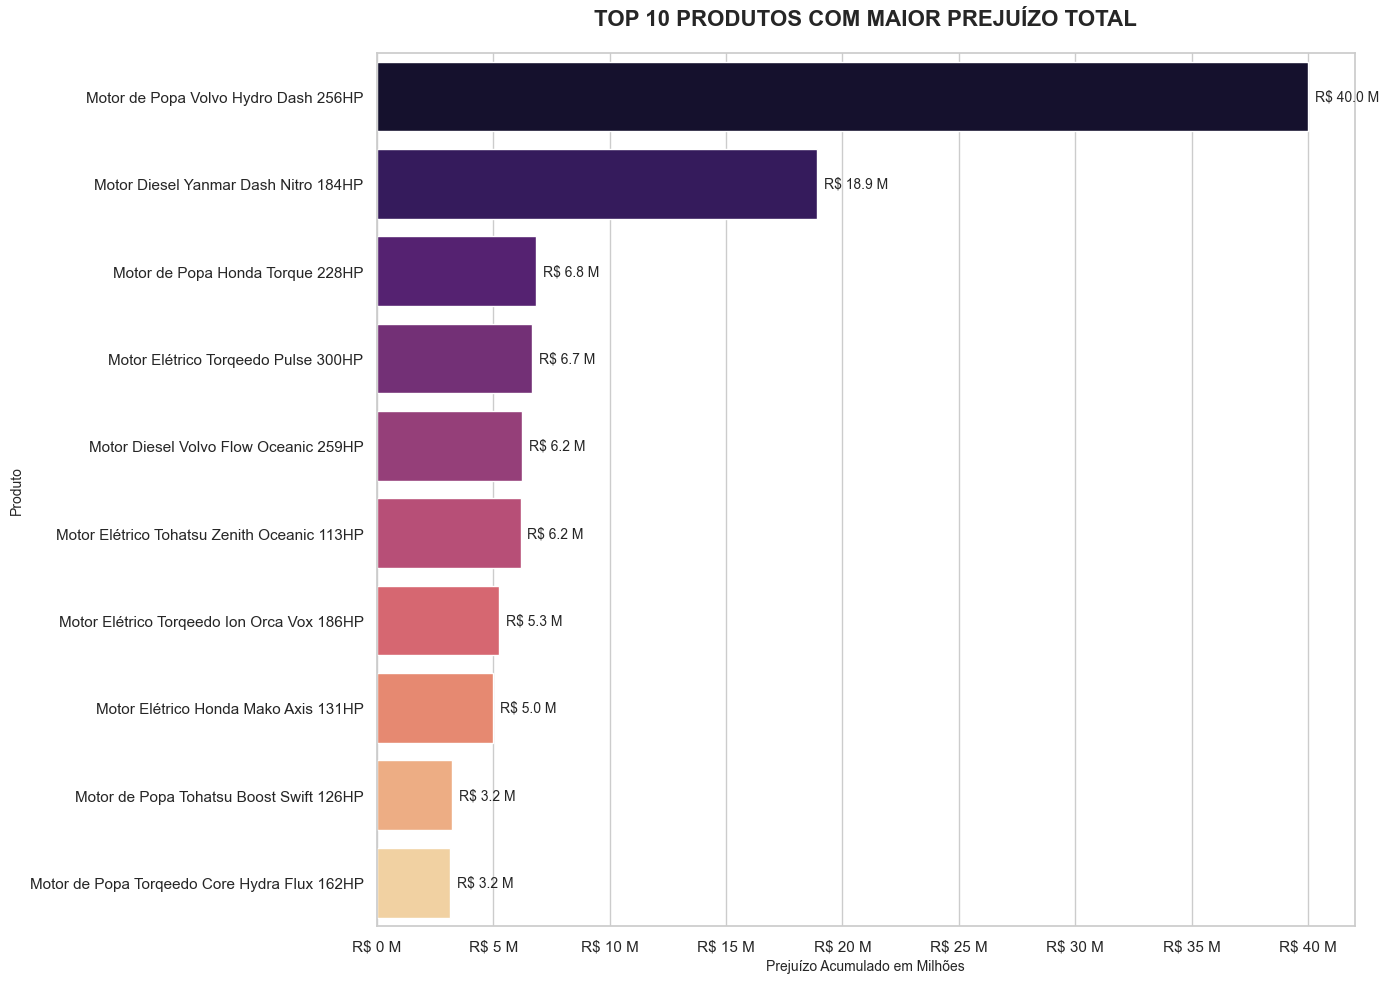

In [41]:
# GRÁFICO DE PREJUÍZO TOTAL POR PRODUTO 
top10_prejuizo = df_dados_agregados[df_dados_agregados['prejuizo_total'] > 0].nlargest(10, 'prejuizo_total')

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")

# DEFININDO FORMATAÇÃO PARA EIXO X EM MILHÕES
def formatacao(x, pos):
    return f'R$ {x/1e6:.0f} M'

# CRUAÇÃO DO GRÁFICO DE BARRAS HORIZONTAIS 
grafico = sns.barplot( data=top10_prejuizo,
                       x='prejuizo_total',
                       y='product_name', 
                       palette='magma',
                       hue='product_name',
                       legend=False)
grafico.xaxis.set_major_formatter(FuncFormatter(formatacao))

for barra in grafico.containers:
    labels = [f'R$ {v.get_width()/1e6:.1f} M' for v in barra]
    grafico.bar_label(barra, labels=labels, padding=5, fontsize=10)

plt.title('TOP 10 PRODUTOS COM MAIOR PREJUÍZO TOTAL', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Prejuízo Acumulado em Milhões', fontsize=10)
plt.ylabel('Produto', fontsize=10)
plt.tight_layout()

# SALVANDO O GRÁFICO
plt.savefig(os.path.join(PATH_PLOTS, 'grafico_prejuizo.png'))
plt.show()

#### **4.3 - Análise Objetiva:**

In [48]:
# INDICANDO O PRODUTO COM MAIOR PREJUÍZO ABSOLUTO
produto_maior_prejuizo = df_dados_agregados.sort_values(by='prejuizo_total', ascending=False).iloc[0]
print(f"Produto com maior prejuízo absoluto: {produto_maior_prejuizo['product_name']} (ID: {produto_maior_prejuizo['id_product']})\nPrejuízo de R$ {produto_maior_prejuizo['prejuizo_total']/1e6:.2f} milhoes\n")
      
# INDICANDO O PRODUTO COM MAIOR PERCENTUAL DE PERDA
produto_maior_percentual_perda = df_dados_agregados[df_dados_agregados['percentual_perda'] > 0].sort_values(by='percentual_perda', ascending=False).iloc[0]
print(f"Produto com maior percentual de perda: {produto_maior_percentual_perda['product_name']} (ID: {produto_maior_percentual_perda['id_product']})\nPercentual de perda: {produto_maior_percentual_perda['percentual_perda']*100:.2f}%\n")

# VERIFICANDO SE O PRODUTO COM MAIOR PREJUÍZO ABSOLUTO É O MESMO QUE O PRODUTO COM MAIOR PERCENTUAL DE PERDA
print("É o mesmo produto com maior prejuízo e maior percentual de perda?\n",
      "SIM" if produto_maior_prejuizo['id_product']==produto_maior_percentual_perda['id_product'] else "NÃO. Produtos diferentes")

Produto com maior prejuízo absoluto: Motor de Popa Volvo Hydro Dash 256HP (ID: 72)
Prejuízo de R$ 40.01 milhoes

Produto com maior percentual de perda: Motor de Popa Volvo Hydro Dash 256HP (ID: 72)
Percentual de perda: 63.44%

É o mesmo produto com maior prejuízo e maior percentual de perda?
 SIM


## **5 - ANÁLISE DE CLIENTES**

In [86]:
# IMPORTANDO BIBLIOTECAS
import pandas as pd
import os
import re

#CONFIGURANDO PATHS
BASE_DIR = os.getcwd()  
PATH_VENDAS = os.path.join(BASE_DIR, '..', 'data', 'raw') 
PATH_PRODUTOS = os.path.join(BASE_DIR, '..', 'data', 'raw') 
PATH_CLIENTES = os.path.join(BASE_DIR, '..', 'data', 'raw')
PATH_PROCESSED = os.path.join(BASE_DIR, '..', 'data', 'processed')


#### **5.1 - Limpeza da categoria de produtos:**

In [87]:
# CARREGANDO OS DADOS
df_vendas =   pd.read_csv(os.path.join(PATH_VENDAS, 'vendas_2023_2024.csv'))
df_produtos = pd.read_csv(os.path.join(PATH_PRODUTOS, 'produtos_raw.csv'))
df_clientes = pd.read_json(os.path.join(PATH_CLIENTES, 'clientes_crm.json'))

# EXIBINDO AS INFORMAÇÕES DOS PRODUTOS
print(df_produtos.info())

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   name             157 non-null    str  
 1   price            157 non-null    str  
 2   code             157 non-null    int64
 3   actual_category  157 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.0 KB
None


In [88]:
# FUNCAO PARA NORMALIZAR AS CATEGORIAS ASSIM COMO A USADA ANTES NO ITEM 2.1
def normalizar_categoria(categoria):
    '''Normaliza a categoria de produtos: retira os espaços, converte para minúsculas e categoriza com base em radicais em comum'''
    categoria = categoria.strip().lower().replace(' ', '')
    if 'el' in categoria:
        return 'eletrônicos'
    elif 'pr' in categoria:
        return 'propulsão'
    elif 'anc' in categoria or 'cor' in categoria:
        return 'ancoragem'
    return categoria

df_produtos['actual_category'] = df_produtos['actual_category'].apply(normalizar_categoria)

#CONFERINDO RESULTADOS DA NORMALIZAÇÃO
print(f"{df_produtos['actual_category'].value_counts()}\nTotal de registros: {df_produtos['actual_category'].value_counts().sum()}")


actual_category
propulsão      53
ancoragem      53
eletrônicos    51
Name: count, dtype: int64
Total de registros: 157


In [89]:
#CONVERSÃO PARA TIPO NUMÉRICO COLUNA PRICE

#ANTES DA CONVERSÃO, REQUER RETIRAR CARACTERES DE CIFRÃO
df_produtos['price'] = df_produtos['price'].astype(str).str.replace('R$', '').str.strip()
df_produtos['price'] = pd.to_numeric(df_produtos['price'], errors='coerce')

# CONFERINDO RESULTADOS DA CONVERSÃO
print(f"Tipo da coluna price: {df_produtos['price'].dtype}")
print(f"Qtd dos valores: {df_produtos['price'].value_counts().sum()}")

# REMOÇÃO DE DUPLICATAS

antes_remocao = len(df_produtos)
df_produtos = df_produtos.drop_duplicates()
depois_remocao = len(df_produtos)
print(f"Registros removidos: {antes_remocao - depois_remocao}")
print(f"Dataset: {depois_remocao} linhas normalizadas e sem duplicatas.")

# SALVANDO O DATASET NORMALIZADO
df_produtos.to_csv(os.path.join(PATH_PROCESSED, 'produtos_normalizados.csv'), index=False)

Tipo da coluna price: float64
Qtd dos valores: 157
Registros removidos: 7
Dataset: 150 linhas normalizadas e sem duplicatas.


#### **5.2 - Calculo do Ticket Médio e da Diversidade de Categorias para cada id_cliente:**

In [90]:
#CONFERINDO AS INFORMAÇÕES DOS CLIENTES
print(df_clientes.info())
display(df_clientes.head(3))

#TRATANDO AS INCONSISTÊNCIAS DE EMAIL
df_clientes['email'] = df_clientes['email'].str.replace('#', '@')
print("Emails corrigidos:")
display(df_clientes.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   full_name  49 non-null     str  
 1   location   49 non-null     str  
 2   code       49 non-null     int64
 3   email      49 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.7 KB
None


,full_name,location,code,email
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com


Emails corrigidos:


,full_name,location,code,email
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro@gmail.com


In [91]:
# OBSERVANDO E TRATANDO AS INCONSISTÊNCIAS EM LOCALIZAÇÃO
print(df_clientes['location'].unique())

<StringArray>
[         'Aratu (Candeias) , BA',                    'PE , Recife',
                  'Rio Grande,RS',                'AC , Rio Branco',
             'PA - Santarém Novo',      'Fortaleza do Tabocão , TO',
                    'PB/Cabedelo',                   'SE - Aracaju',
               'PB - João Pessoa',                  'Santarém / PA',
              'BA - Porto Seguro',      'TO , Fortaleza do Tabocão',
                  'PA / Santarém',               'AM , Itacoatiara',
        'Fortaleza do Tabocão,TO',                   'Fortaleza,CE',
                   'MS - Corumbá',                  'Santarém - PA',
                    'Maceió / AL',             'PA , Santarém Novo',
                  'AC,Rio Branco',                   'SE / Aracaju',
                    'Santos - SP',                    'Laguna / SC',
                'ES / São Mateus',                      'Manaus/AM',
                    'Salvador,BA',                  'PR , Antonina',
                   '

In [92]:
#CRIANDO UMA FUNÇÃO PARA SEPARAR CIDADE E ESTADO UF
def tratando_localizacao(localizacao):
   '''Recebe a localização, separa por vírgula, barra ou hífen, e identifica a cidade e o estado UF.'''
   separacao = [p.strip() for p in re.split(r'[,/-]', str(localizacao))]
   uf = next((p.upper() for p in separacao if len(p) == 2), None)
   cidade = next((p for p in separacao if len(p) != 2), None)
   return pd.Series([cidade, uf])

#APLICANDO A FUNÇÃO DE TRATAMENTO DE LOCALIZAÇÃO E REMOVENDO A COLUNA ORIGINAL SUJA
df_clientes[['cidade','UF']] = df_clientes['location'].apply(tratando_localizacao)
df_clientes = df_clientes.drop(columns=['location'])
display(df_clientes[['cidade', 'UF']].head(3))

,cidade,UF
0,Aratu (Candeias),BA
1,Recife,PE
2,Rio Grande,RS


In [93]:
#AGREGANDO OS DADOS DE VENDAS COM OS PRODUTOS
df_vendas_produtos = pd.merge(df_vendas, df_produtos, left_on='id_product', right_on='code')
print(df_vendas_produtos.head(3))

   id  id_client  id_product  qtd    total   sale_date  \
0   0         42         105   11   3405.0  2023-09-10   
1   1          3         136    9  16873.9  15-09-2024   
2   2         25         139    7   9475.3  2024-08-13   

                                  name    price  code actual_category  
0         Cabo de Nylon Danforth Prime   309.54   105       ancoragem  
1       Cabo de Nylon Bruce Flux Hydro  1973.50   136       ancoragem  
2  Boia de Arqueamento Danforth Torque  1424.88   139       ancoragem  


In [94]:
# UNINDO O RESULTADO COM OS DADOS DE CLIENTES
df_clientes_transacoes = pd.merge(df_vendas_produtos, df_clientes, left_on='id_client', right_on='code')
print(df_clientes_transacoes.head(3))

   id  id_client  id_product  qtd    total   sale_date  \
0   0         42         105   11   3405.0  2023-09-10   
1   1          3         136    9  16873.9  15-09-2024   
2   2         25         139    7   9475.3  2024-08-13   

                                  name    price  code_x actual_category  \
0         Cabo de Nylon Danforth Prime   309.54     105       ancoragem   
1       Cabo de Nylon Bruce Flux Hydro  1973.50     136       ancoragem   
2  Boia de Arqueamento Danforth Torque  1424.88     139       ancoragem   

                                full_name  code_y  \
0                       Márcia Figueiredo      42   
1          Daniel Farias Ribeiro Teixeira       3   
2  Femininos Antunes Lopes Ribeiro Amaral      25   

                                               email  \
0                   márcia.figueiredo@protonmail.com   
1           farias.teixeira.daniel.ribeiro@gmail.com   
2  femininos.antunes.amaral.lopes.ribeiro@icloud.com   

                      cidade

In [95]:
# CALCULANDO AS MÉTRICAS POR CLIENTE
df_metricas = df_clientes_transacoes.groupby('id_client').agg(
    full_name=('full_name', 'first'),
    faturamento_total=('total', 'sum'),
    frequencia=('id', 'nunique'),
    diversidade_categorias=('actual_category', 'nunique')).reset_index()

# CALCULANDO O TICKET MÉDIO
df_metricas['ticket_medio'] = df_metricas['faturamento_total'] / df_metricas['frequencia']
print(df_metricas.head())

df_metricas.to_csv(os.path.join(PATH_PROCESSED, 'metricas_clientes.csv'), index=False)

   id_client                             full_name  faturamento_total  \
0          1            Femininos Oliveira Antunes        51092500.05   
1          2  Fernanda Azevedo Soares Nunes Vieira        65652931.35   
2          3        Daniel Farias Ribeiro Teixeira        59575349.10   
3          4                        Thiago Moreira        50691754.40   
4          5                         Pedro Freitas        58592802.70   

   frequencia  diversidade_categorias   ticket_medio  
0         190                       3  268907.895000  
1         220                       3  298422.415227  
2         207                       3  287803.618841  
3         207                       3  244887.702415  
4         202                       3  290063.379703  


In [96]:
#OBSERVANDO QUANTOS CLIENTES COMPRARAM MAIS DE 3 CATEGORIAS DIFERENTES
df_clientes_categorias = df_metricas[df_metricas['diversidade_categorias'] >= 3]
print(f"Numero de clientes que compraram pelo menos 3 categorias: {df_clientes_categorias.shape[0]}")

Numero de clientes que compraram pelo menos 3 categorias: 49


#### **5.3 - TOP 10 Clientes com o maior Ticket Médio:**

In [98]:
#SELECIONANDO OS 10 CLIENTES DE ELITE COM BASE NO TICKET MÉDIO
top_10_clientes = df_metricas.sort_values(by=['ticket_medio', 'id_client'], ascending=[False, True]).head(10)
top_10_clientes = top_10_clientes.sort_values(by='id_client', ascending=True)
display(top_10_clientes)

,id_client,full_name,faturamento_total,frequencia,diversidade_categorias,ticket_medio
1,2,Fernanda Azevedo Soares Nunes Vieira,65652931.35,220,3,298422.415227
4,5,Pedro Freitas,58592802.70,202,3,290063.379703
8,9,Lucas Guedes Cunha Lopes,66788855.35,218,3,306370.896101
21,22,Daniela Borges Vieira Farias Mendonça,59581398.75,198,3,300916.155303
27,28,Bianca Rodrigues,60826837.25,204,3,298170.770833
35,36,Francisca Ribeiro Pinheiro,62791038.15,215,3,292051.340233
37,38,Mateus Antunes,57093331.15,195,3,292786.313590
41,42,Márcia Figueiredo,72187369.50,222,3,325168.331081
45,46,Ana Silva Costa Farias Coelho,59126834.35,199,3,297119.770603
46,47,Gabriela Barros Lacerda,64003343.75,190,3,336859.703947


#### **5.4 - Categoria de produto com maior quantidade total de itens comprados entre o TOP 10 clientes:**

In [109]:
# IDENTIFICANDO A CATEGORIA DOMINANTE ENTRE OS CLIENTES DE ELITE
df_vendas_elite = df_clientes_transacoes[df_clientes_transacoes['id_client'].isin(top_10_clientes['id_client'])]
categoria_dominante = df_vendas_elite.groupby('actual_category')['qtd'].sum().sort_values(ascending=False)
display(categoria_dominante.head(1))
print(f"A categoria dominante entre os clientes de elite é '{categoria_dominante.idxmax()}' somando {categoria_dominante.max()} itens.")

actual_category
propulsão    6030
Name: qtd, dtype: int64

A categoria dominante entre os clientes de elite é 'propulsão' somando 6030 itens.


## **6 - DIMENSÃO DO CALENDÁRIO**


In [110]:
import pandas as pd
import os
import duckdb
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns

#### **6.1 e 6.2 - Dimensão de datas SQL + Vendas para análise:**

- Usando duckdb para emular o SQL.
- compatível com POSTGRESQL.


In [112]:
#CONFIGURANDO PATHS
BASE_DIR = os.getcwd()
PATH_VENDAS= os.path.join(BASE_DIR, '..', 'data', 'raw', 'vendas_2023_2024.csv')

#IMPORTANDO O DATASET DE VENDAS
vendas_2023_2024 = pd.read_csv(PATH_VENDAS)

#CONSULTA SQL 
query_sql = r"""
WITH vendas_tratadas AS (
    SELECT 
        CASE 
            WHEN regexp_matches(sale_date, '^\d{4}') THEN CAST(sale_date AS DATE)
            WHEN regexp_matches(sale_date, '^\d{1,2}-') THEN CAST(strptime(sale_date, '%d-%m-%Y') AS DATE)
            ELSE CAST(sale_date AS DATE)
        END AS data,
        total
    FROM vendas_2023_2024
    WHERE sale_date IS NOT NULL AND sale_date <> ''
),

limites AS (
    SELECT MIN(data) AS data_inicio, MAX(data) AS data_fim FROM vendas_tratadas
),

dim_calendario AS (
    SELECT CAST(t.range AS DATE) AS data
    FROM (
        SELECT unnest(generate_series(
            (SELECT data_inicio FROM limites), 
            (SELECT data_fim FROM limites), 
            interval '1 day'
        )) AS range
    ) AS t
),

dim_calendario_pt AS (
    SELECT 
        data,
        CASE dayofweek(data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana,
        dayofweek(data) AS cod_dia
    FROM dim_calendario
),

vendas_por_dia AS (
    SELECT data, SUM(total) AS total_dia FROM vendas_tratadas GROUP BY data
),

base_final AS (
    SELECT 
        c.dia_semana,
        c.cod_dia,
        COALESCE(v.total_dia, 0) AS faturamento_final
    FROM dim_calendario_pt c
    LEFT JOIN vendas_por_dia v ON c.data = v.data
)

SELECT 
    dia_semana,
    ROUND(AVG(faturamento_final), 2) AS media_vendas
FROM base_final
GROUP BY dia_semana, cod_dia
ORDER BY media_vendas ASC;
"""
df_resultado = duckdb.query(query_sql).to_df()
display(df_resultado)

,dia_semana,media_vendas
0,Domingo,3319503.57
1,Segunda-feira,3465137.71
2,Quarta-feira,3535265.63
3,Quinta-feira,3626232.44
4,Terça-feira,3627045.76
5,Sábado,3710540.55
6,Sexta-feira,3715003.41


Indica o Domingo como dia de menor mpedia de vendas (3.32 milhões)

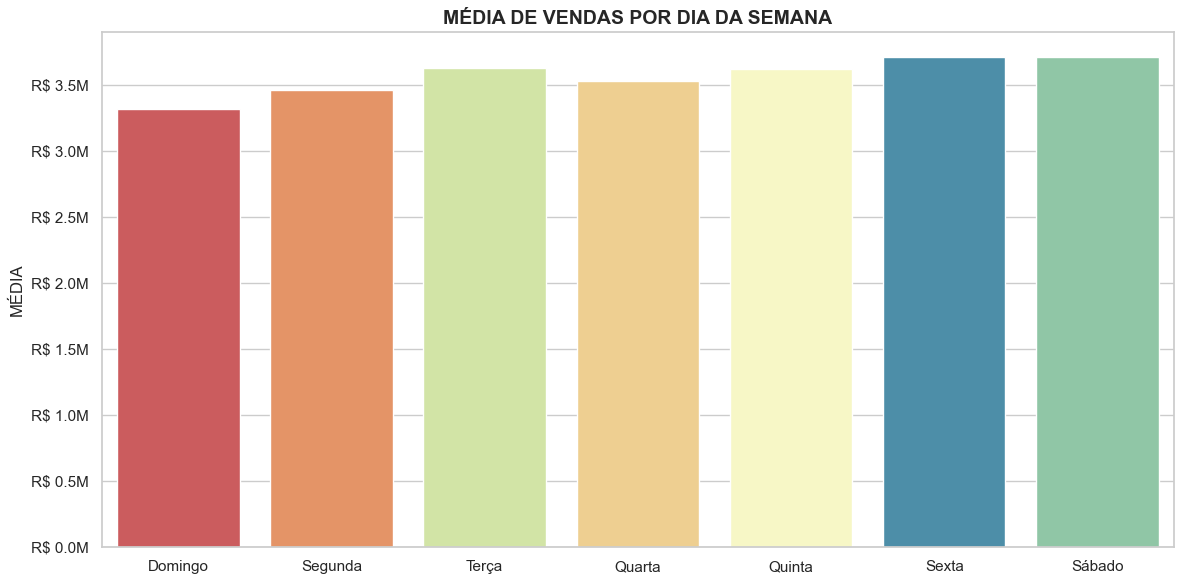

In [113]:
# GRAFICO DE BARRAS PARA MÉDIA DE VENDAS POR DIA DA SEMANA

df_resultado['dia_semana'] = df_resultado['dia_semana'].str.replace('-feira', '', regex=False)
ordem = ['Domingo','Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado']

media_dia = df_resultado.rename(columns={'media_vendas': 'total'})

plt.figure(figsize=(12, 6))
sns.barplot(data=media_dia,
            x='dia_semana',
            y='total',
            hue='dia_semana',
            palette='Spectral',
            legend=False,
            order=ordem)

plt.title('MÉDIA DE VENDAS POR DIA DA SEMANA', fontsize=14, fontweight='bold')
plt.xlabel('DIA DA SEMANA', fontsize=12)
plt.ylabel('MÉDIA (R$)', fontsize=12)

def formatando(x, pos):
    return f'R$ {x/1e6:.1f}M'

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(formatando))

plt.title('MÉDIA DE VENDAS POR DIA DA SEMANA', fontsize=14, weight='bold')
plt.xlabel('')
plt.ylabel('MÉDIA')
plt.xticks()
plt.tight_layout()
plt.show()

## **7 - PREVISÃO DE DEMANDA**

In [122]:
# IMPORTANDO BIBLIOTECAS
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error

#### **7.1 - Modelo Baseline:**

In [123]:
# CONFIGURAÇÃO DE PATH
BASE_DIR = os.getcwd()
PATH_VENDAS = os.path.join(BASE_DIR, '..', 'data', 'raw', 'vendas_2023_2024.csv')
PATH_PRODUTOS = os.path.join(BASE_DIR, '..', 'data', 'raw', 'produtos_raw.csv')
PATH_PROCESSED = os.path.join(BASE_DIR, '..', 'data', 'processed')
PATH_PLOTS = os.path.join(BASE_DIR, '..', 'notebook', 'plots')
PRODUTO_ALVO = "Motor de Popa Yamaha Evo Dash 155HP"

#CARREGANDO OS DATASETS
vendas = pd.read_csv(PATH_VENDAS)
produtos = pd.read_csv(PATH_PRODUTOS)

#TRATAMENTO DE DATAS
def format_saledata(valor):
    if not isinstance(valor, str): return valor
    try:
        if valor[4] == '-': return pd.to_datetime(valor, format='%Y-%m-%d')
        else: return pd.to_datetime(valor, format='%d-%m-%Y')
    except: return pd.to_datetime(valor, errors='coerce')

#MERGE ENTRE VENDAS E PRODUTOS PARA FILTRAR PELO NOME DO PRODUTO ALVO
df_merged = pd.merge(vendas, produtos, left_on='id_product', right_on='code', how='inner')
df_filtrado = df_merged[df_merged['name'] == PRODUTO_ALVO].copy()
df_filtrado['sale_date'] = df_filtrado['sale_date'].apply(format_saledata)

# CRIAÇÃO DE CALENDARIO (01/01/23 a 31/01/24)
vendas_diarias = df_filtrado.groupby('sale_date')['qtd'].sum().reset_index()
calendario = pd.DataFrame({'sale_date': pd.date_range(start='2023-01-01', end='2024-01-31', freq='D')})
df_final = pd.merge(calendario, vendas_diarias, on='sale_date', how='left').fillna(0)

#FAZENDO O BASELINE DE MÉDIA MÓVEL 7 DIAS
df_final['previsao'] = df_final['qtd'].shift(1).rolling(window=7).mean().fillna(0)

#SEPARANDO TREINO E TESTE
treino = df_final[df_final['sale_date'] <= '2023-12-31'].copy()
teste = df_final[(df_final['sale_date'] >= '2024-01-01') & (df_final['sale_date'] <= '2024-01-31')].copy()

#MÉTRICA MAE
mae = mean_absolute_error(teste['qtd'], teste['previsao'])

df_previsao = df_final.to_csv(os.path.join(PATH_PROCESSED, 'previsao_ID54.csv'), index=False)

#EXIBINDO RESULTADOS    

print(f"RESULTADOS PARA: {PRODUTO_ALVO}")

print(f"MAE: {mae:.4f}")


RESULTADOS PARA: Motor de Popa Yamaha Evo Dash 155HP
MAE: 0.9954


####  **7.2 - Comparação por MAE — Mean Absolute Error:**

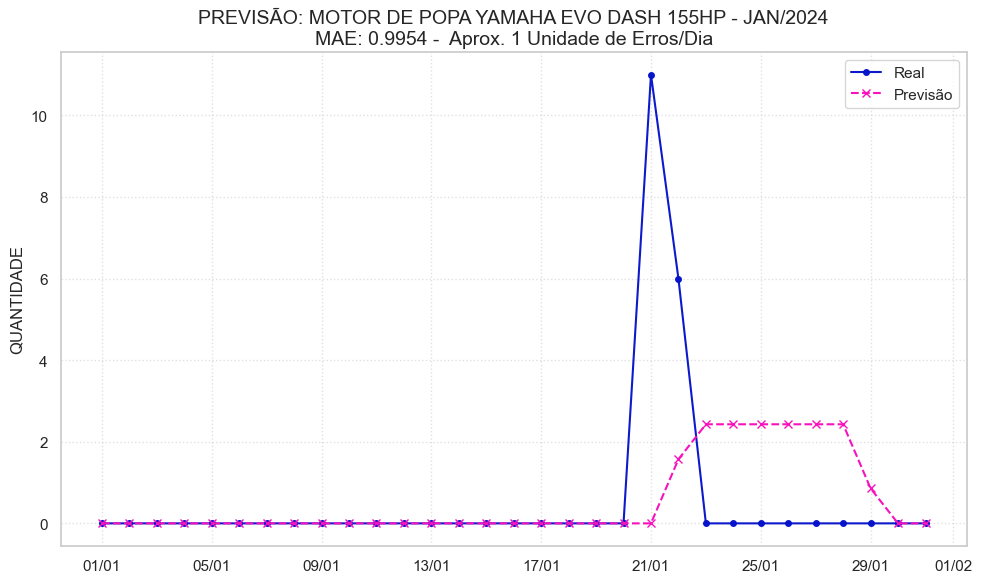

In [124]:
# GERANDO O GRÁFICO DE COMPARAÇÃO ENTRE REAL E PREVISÃO
plt.figure(figsize=(10, 6))

plt.plot(teste['sale_date'], teste['qtd'],
         label='Real',
         color="#0411caf6",
         marker='o',
         markersize=4)

plt.plot(teste['sale_date'], teste['previsao'],
         label='Previsão',
         color="#f712bd",
         linestyle='--',
         marker='x')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.xticks(rotation=45)
plt.title(
    f'PREVISÃO: {(PRODUTO_ALVO).upper()} - JAN/2024\nMAE: {mae:.4f} -  Aprox. {mae:.0f} Unidade de Erros/Dia', fontsize=14)
plt.ylabel('QUANTIDADE', fontsize=12)
plt.xlabel('')

plt.xticks(rotation=0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

# SALVANDO O GRÁFICO
plt.savefig(os.path.join(PATH_PLOTS, 'grafico_previsao_jan2024_ID54.png'))
plt.show()

#### **Conclusões objetivas:**

**a) Baseline é adequado para esse produto?**

Não. Este produto tem a caracteristica de ter uma demanda inconstante, com baixa previsibilidade de compras.


O modelo de média móvel funciona de modo efetivo para produtos que de fato tenham a demanda mais constante.


**b) Limitação do método:**

Uma limitação consideravel é visualizar o passado imediato da semana, e com isso, a média móvel não consegue antecipar as tendências ou picos.


Ela acaba sendo mais reativa ao que já aconteceu, deslocando a previsão no tempo e falhando em capturar a sazonalidade de produtos como este ou outras imprevisibilidaddes antes que ocorram.